In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

from itertools import combinations
from sklearn.model_selection import ParameterGrid

from bandit import Bandit
from agents import EpsilonGreedyAgent
from estimators import ConstantStepSizeEstimator, SampleAverageEstimator
from simulation import bandit_agent_run, run_simulation, run_experiment_parallel

%load_ext autoreload
%autoreload 2

# 10-armed Bandit Testbed

## Initialize a specific 10-armed bandit

In [2]:
bandit = Bandit(10)

In [3]:
bandit._q_true

array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
       -1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393])

In [4]:
[bandit.sample(a).item() for a in range(0, 10)];

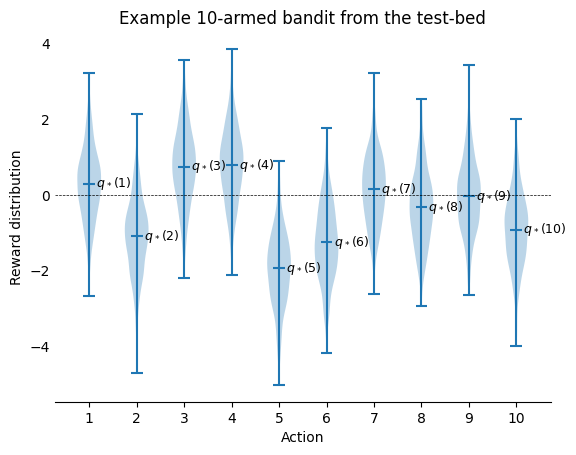

In [5]:
actions = range(0, 10)
rewards = [bandit.sample(a, 500) for a in actions]

# Create violin plot with means enabled
fig, ax = plt.subplots()
plt.title("Example 10-armed bandit from the test-bed")
parts = ax.violinplot(rewards, showmeans=True)

plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_xticks(range(1,11), labels=[f"{x}" for x in range(1, 11)])
plt.xlabel("Action")
plt.ylabel("Reward distribution")

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(axis='y', which='both', length=0)

# Extract mean segments from 'cmeans' LineCollection
mean_collection = parts["cmeans"]
paths = mean_collection.get_paths()

# Loop through paths to get coordinates and place text labels
for i, path in enumerate(paths):
  # Each path has 2 vertices for the mean horizontal line segment: start and end
  vertices = path.vertices
  mean_x = np.mean(vertices[:, 0])
  mean_y = np.mean(vertices[:, 1])

  # Add text label above or beside the mean indicator
  ax.text(
      mean_x,
      mean_y,
      f"  $q_*({i+1})$",
      verticalalignment="center",
      horizontalalignment="left",
      fontsize=9,
      color="black",
  )

plt.savefig("../images/figure_2_1.png", bbox_inches="tight")

## $\epsilon$-greedy action-value method

In [6]:
%%time

# Bandit parameters
k = 10          # number of arms in the bandit

# Agent parameters
epsilons = [0.0, 0.01, 0.1]

# Simulation parameters
T = 3000  # number of timesteps played
R = 2000  # number of runs to play in the simulation

average_rewards = np.empty((len(epsilons), T))
percent_optimal_actions = np.empty((len(epsilons), T))

for i, epsilon in enumerate(epsilons):
    average_rewards[i], percent_optimal_actions[i] = run_experiment_parallel(R, epsilon, T, k, q_true_var=1, q_var=1, estimator=SampleAverageEstimator)

CPU times: user 8.15 s, sys: 1.9 s, total: 10.1 s
Wall time: 1min 59s


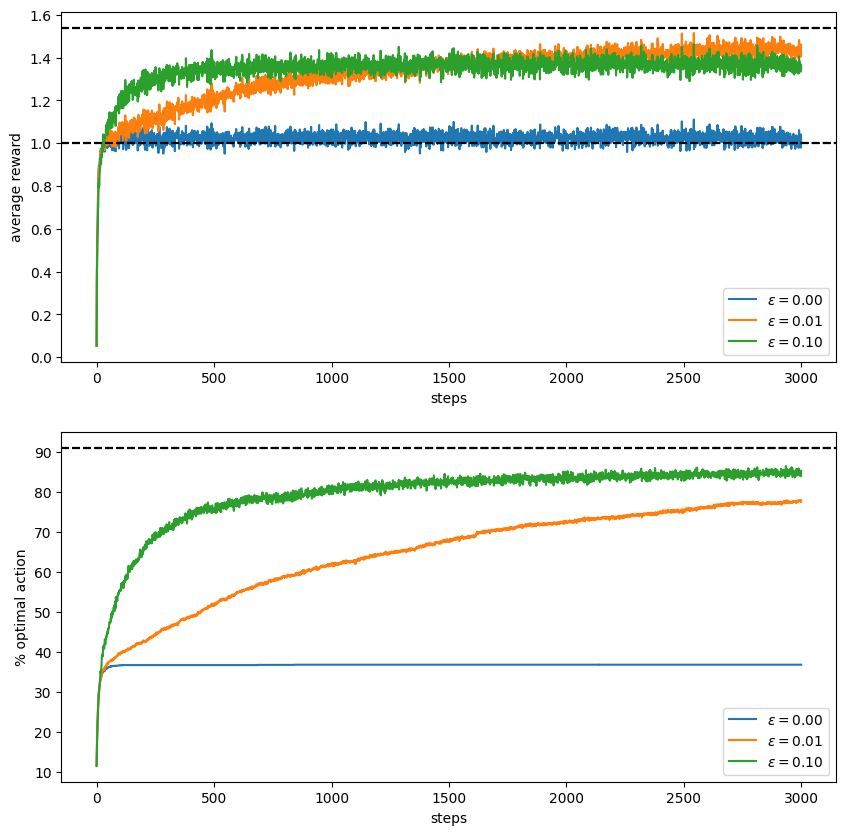

In [7]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label="$\\epsilon = %.02f$" % (epsilon))
    plt.axhline(y=1.54, color='k', linestyle='--')
    plt.axhline(y=1, color='k', linestyle='--')
plt.xlabel("steps")
plt.ylabel("average reward")
plt.legend()

plt.subplot(2, 1, 2)
for i, epsilon in enumerate(epsilons):
    plt.plot(percent_optimal_actions[i], label="$\\epsilon = %.02f$" % (epsilon))
    plt.axhline(y=91, color='k', linestyle='--')
plt.xlabel("steps")
plt.ylabel("% optimal action")
plt.legend()

plt.savefig("../images/figure_2_2.png", bbox_inches="tight")

## Does the pure greedy algorithm always converge to an average reward of 1?

In [8]:
# Bandit parameters
epsilon = 0

# Simulation parameters
T = 1000  # number of timesteps played
R = 200  # number of runs to play in the simulation

In [9]:
# Define search space
variables = ["k", "q_true_var", "q_var"]
start_values = {
    "k": 10,
    "q_true_var": 1.0,
    "q_var": 1.0
}
var_names = {
    "k": "# Arms",
    "q_true_var": "Variance",
    "q_var": "Noise variance"
}

k_range = list(range(10, 201, 10))
q_true_var_range = np.round(np.arange(1.0, 3.01, 0.1), 1)
q_var_range = np.round(np.arange(0.0, 10.01, 0.5), 1)

scenarios = [
    {"k": k_range, "q_true_var": q_true_var_range, "q_var": [start_values["q_var"]]},
    {"k": k_range, "q_true_var": [start_values["q_true_var"]],             "q_var": q_var_range},
    {"k": [start_values["k"]],    "q_true_var": q_true_var_range,  "q_var": q_var_range},
]

In [10]:
%%time

try:
    len(limits.keys())
except NameError:
    limits = {}

for params in ParameterGrid(scenarios):
    key = (params["k"], params["q_true_var"], params["q_var"])

    # Skip already computed values
    if key in limits:
        continue

    rewards, optimal = run_experiment_parallel(R, epsilon, T, params["k"], q_true_var=params["q_true_var"], q_var=params["q_var"], estimator=SampleAverageEstimator)
    limits[key] = rewards[-int(T/10):].mean().item()

df = pd.Series(limits).rename_axis(["k", "q_true_var", "q_var"]).reset_index(name="reward")

CPU times: user 4min 21s, sys: 29.8 s, total: 4min 51s
Wall time: 40min 59s


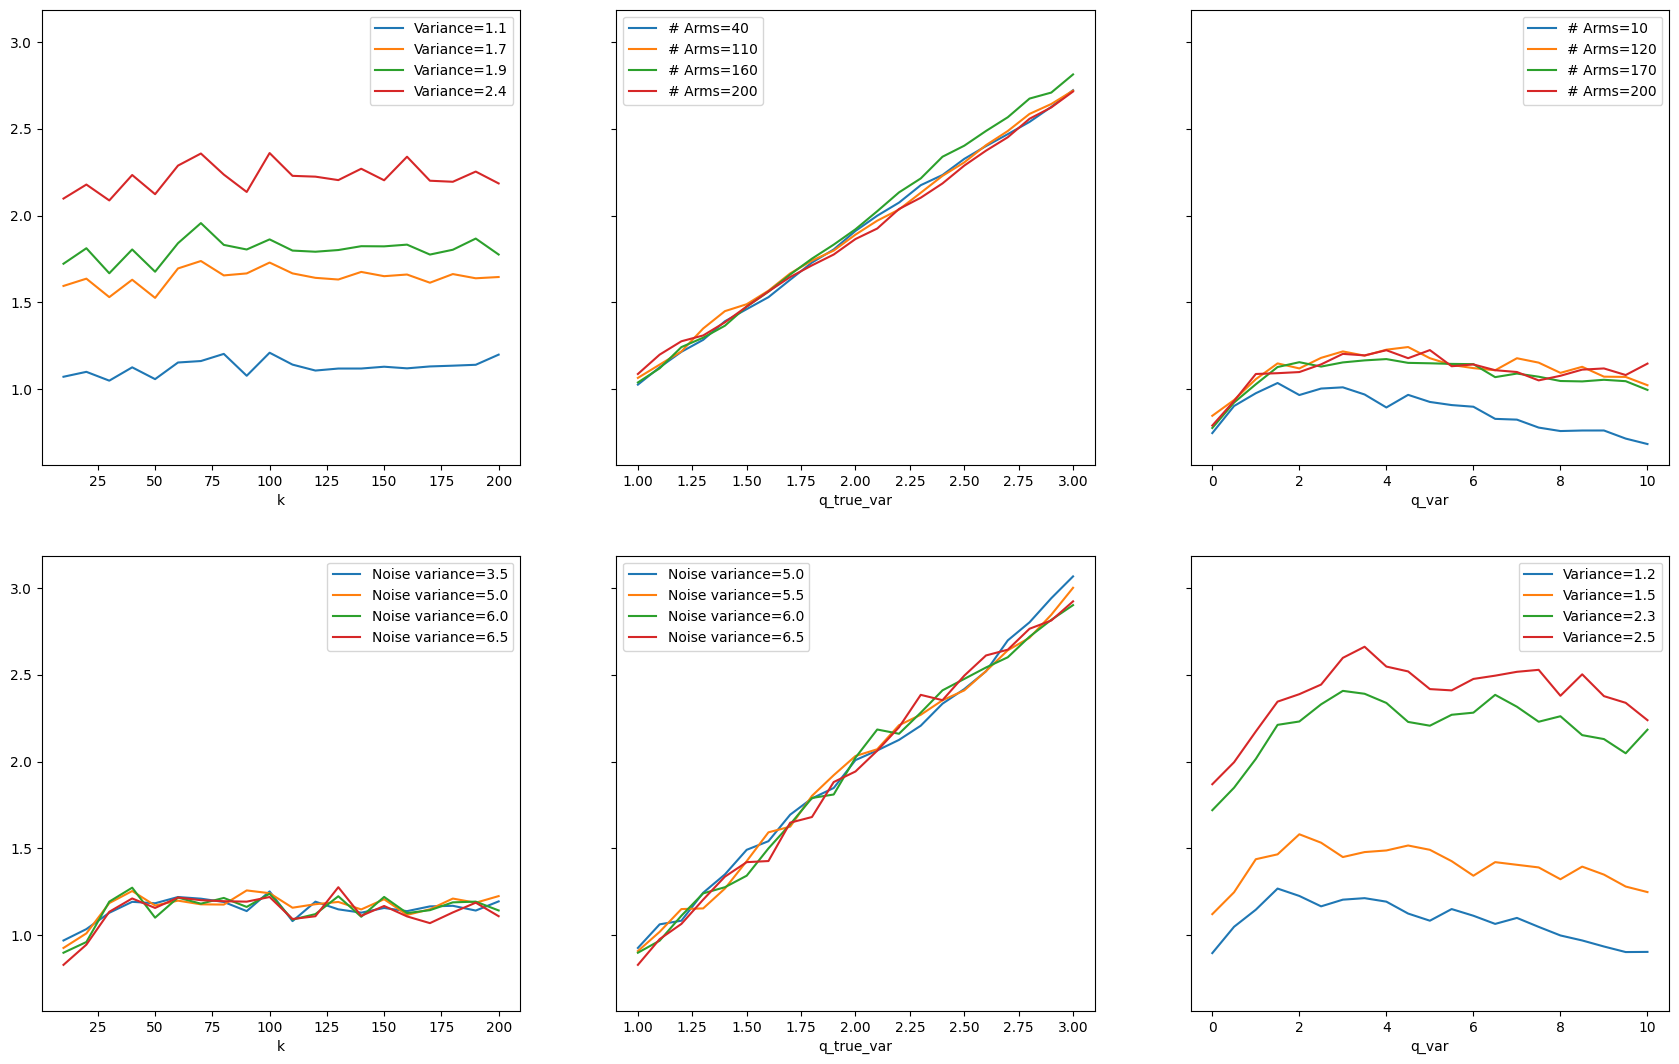

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(21, 13), sharey=True);

# Loop through all variables on x axis
for i, var1 in enumerate(variables):
    other_vars = [v for v in variables if v!=var1]

    # Loop through second variables for multiline plot
    for j, var2 in enumerate(other_vars):
        var3 = [v for v in variables if v not in (var1, var2)][0]
        var2_sample = sorted(random.sample(list(df[var2].unique()), 4))

        # Select data for this plot
        df_plot = df[(df[var3] == start_values[var3]) & df[var2].isin(var2_sample)]

        # Draw a line plot for each value of var2
        for val, group in df_plot.groupby(var2):
            group.sort_values(var1).plot(x=var1, y="reward", ax=axes[j,i], label=f"{var_names[var2]}={val}")

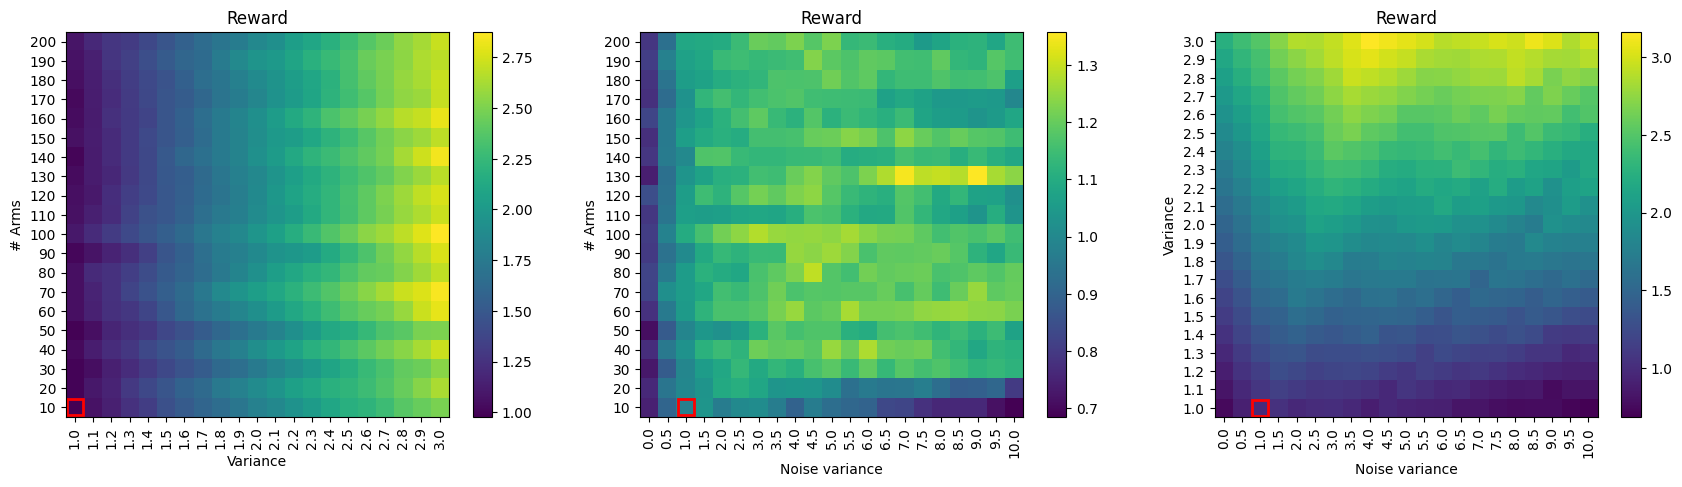

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, (var1, var2) in zip(axes, combinations(variables, 2)):
    var3 = [v for v in variables if v not in (var1, var2)][0]

    # Reward as a function of var1 and var2
    df_plot = df[df[var3] == start_values[var3]].pivot(index=var1, columns=var2, values="reward")
    im = ax.imshow(df_plot, aspect="auto", cmap="viridis", origin="lower", interpolation='nearest')

    # tick labels from the pivot's index/columns
    ax.set_xticks(range(len(df_plot.columns)));
    ax.set_xticklabels(df_plot.columns, rotation=90);
    ax.set_xlabel(var_names[var2])
    ax.set_yticks(range(len(df_plot.index)));
    ax.set_yticklabels(df_plot.index);
    ax.set_ylabel(var_names[var1]);

    # Title, and colorbar
    ax.set_title("Reward")
    fig.colorbar(im)

    # Highlight the initial values
    # convert data coords -> pixel index and plot marker
    x_idx = df_plot.columns.get_loc(start_values[var2])
    y_idx = df_plot.index.get_loc(start_values[var1])
    ax.plot(x_idx, y_idx, marker="s", color="red", markersize=12, markeredgewidth=2, markerfacecolor="none")

# Non-stationary Bandits Testbed

### Set up Bandit with drifting q_true values

In [13]:
# Bandit parameters
k = 10  # number of arms in the bandit
q_true_mean = 0.0
q_true_var = 0.0
drift_var = 0.01

# Agent and test parameters
T = 10000  # number of timesteps played
epsilon = 0.1
R = 2000  # number of runs to play in the simulation

Initial optimal reward:	 0.0
Final optimal reward:	 0.98735


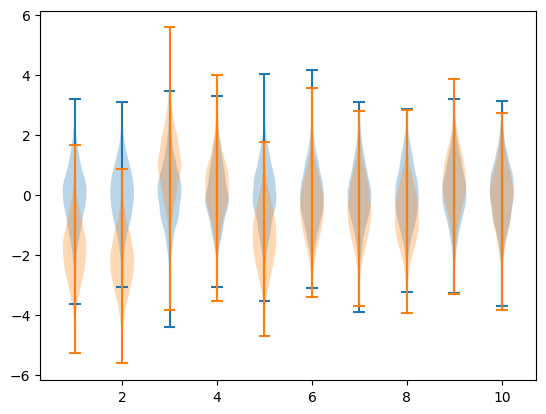

In [14]:
# Visualize an example
bandit = Bandit(k, q_true_mean=q_true_mean, q_true_var=q_true_var, drift_var=drift_var)
q_true_values = np.zeros((k, T))

rewards_start = [bandit.sample(a, R) for a in range(0, k)]
print(f"Initial optimal reward:\t {round(bandit._q_true.max().item(), 5)}")

# Take a number of time steps, at each of which the q_true valus take independent random walks
for i in range(T):
    q_true_values[:, i] = bandit._q_true
    bandit.reward(0)
rewards_end = [bandit.sample(a, R) for a in range(0, k)]
print(f"Final optimal reward:\t {round(bandit._q_true.max().item(), 5)}")

plt.violinplot(rewards_start)
plt.violinplot(rewards_end);

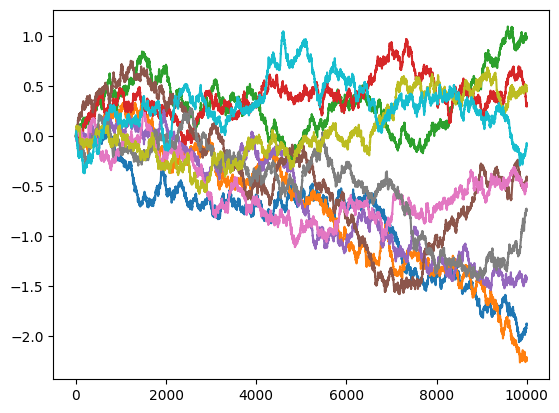

In [15]:
plt.plot(q_true_values.T);

### Compare sample-average with constant step-size action-value methods

Average reward for sample average:  0.7037529671728684
Average reward for constant step size:  0.8696984433881544
CPU times: user 10.2 s, sys: 3.94 s, total: 14.1 s
Wall time: 3min 46s


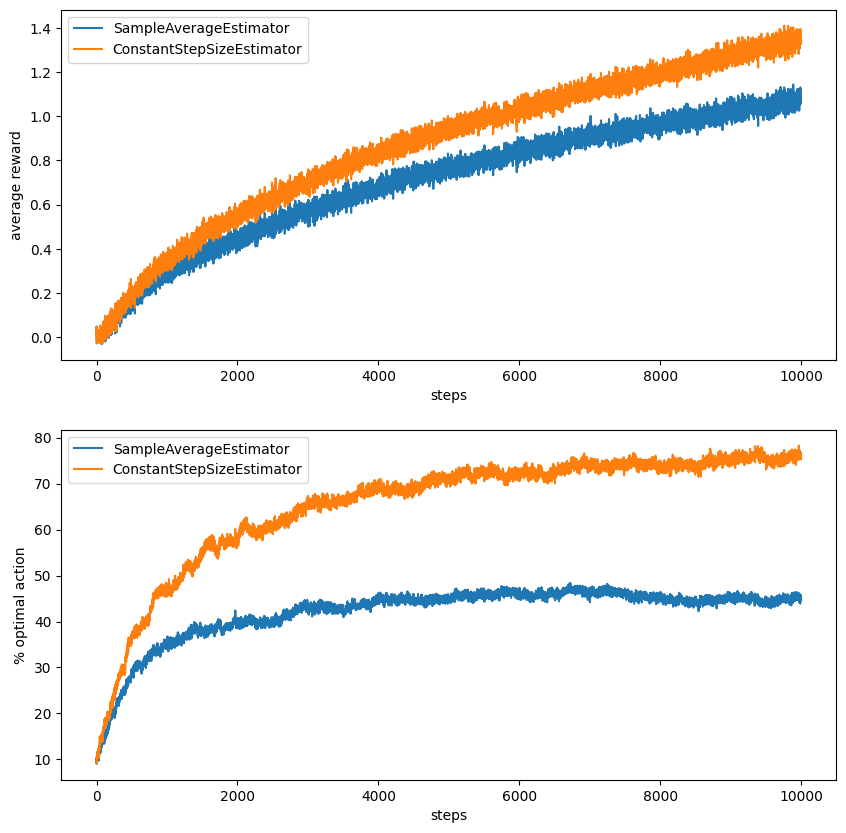

In [16]:
%%time

# Bandit parameters
k = 10  # number of arms in the bandit
q_true_mean = 0.0
q_true_var = 0.0
drift_var = 0.01

# Agent parameters
epsilon = 0.1
estimators = [SampleAverageEstimator, ConstantStepSizeEstimator]

# Simulation parameters
T = 10000  # number of timesteps played
R = 2000  # number of runs to play in the simulation

average_rewards = np.empty((len(estimators), T))
percent_optimal_actions = np.empty((len(estimators), T))

for i, estimator in enumerate(estimators):
    average_rewards[i], percent_optimal_actions[i] = run_experiment_parallel(
        R, epsilon, T, k, estimator, 
        q_true_mean=q_true_mean, q_true_var=q_true_var, drift_var=drift_var
    )


print("Average reward for sample average: ", np.mean(average_rewards[0]))
print("Average reward for constant step size: ", np.mean(average_rewards[1]))


plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
for i, estimator in enumerate(estimators):
    plt.plot(average_rewards[i], label=estimator.__name__)
plt.xlabel("steps")
plt.ylabel("average reward")
plt.legend()

plt.subplot(2, 1, 2)
for i, estimator in enumerate(estimators):
    plt.plot(percent_optimal_actions[i], label=estimator.__name__)
plt.xlabel("steps")
plt.ylabel("% optimal action")
plt.legend()

plt.savefig('../images/figure_2_2_ns.png', bbox_inches="tight")